In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from xgboost import XGBRegressor

df = pd.read_csv('analysed_demand_data_2025.csv')
df

,Unnamed: 0,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,...,False,False,True,NaN,NaN,NaN,19918.000000,5405,0.271363,14513
1,1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,...,False,False,True,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809
2,2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,...,False,False,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091
3,3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,...,False,False,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345
4,4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,...,False,False,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,17515,2025-12-31 21:30:00,44,28633,30690,26868,3994,6606,0,22126,...,False,False,False,27896.0,29072.0,29056.0,28162.041667,3994,0.148653,22874
17516,17516,2025-12-31 22:00:00,45,27381,30212,25722,4027,6606,0,22126,...,False,False,False,26868.0,27896.0,27917.0,28116.312500,4027,0.156559,21695
17517,17517,2025-12-31 22:30:00,46,26563,29786,25049,4059,6606,0,22126,...,False,False,False,25722.0,26868.0,26598.0,28084.041667,4059,0.162042,20990
17518,17518,2025-12-31 23:00:00,47,25481,30558,23955,4115,6606,0,22126,...,False,False,True,25049.0,25722.0,25493.0,28052.000000,4115,0.171780,19840


In [5]:
df.drop('Unnamed: 0', axis='columns', inplace=True)
df.head()

,timestamp,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,is_morning_peak,is_evening_peak,night,lagged_demand_30m,lagged_demand_1h,lagged_demand_24h,demand_rolling_mean_24h,renewable_gen,renewable_pct,net_demand
0,2025-01-01 00:00:00,1,21036,26215,19918,5405,6606,0,19270,0,...,False,False,True,NaN,NaN,NaN,19918.000000,5405,0.271363,14513
1,2025-01-01 00:30:00,2,21222,26063,20167,5358,6606,0,19270,0,...,False,False,True,19918.0,NaN,NaN,20042.500000,5358,0.265682,14809
2,2025-01-01 01:00:00,3,21385,25734,20328,5237,6606,0,19270,0,...,False,False,True,20167.0,19918.0,NaN,20137.666667,5237,0.257625,15091
3,2025-01-01 01:30:00,4,20473,24988,19460,5115,6606,0,19270,0,...,False,False,True,20328.0,20167.0,NaN,19968.250000,5115,0.262847,14345
4,2025-01-01 02:00:00,5,19634,24912,18654,5080,6606,0,19270,0,...,False,False,True,19460.0,20328.0,NaN,19705.400000,5080,0.272328,13574


<Axes: >

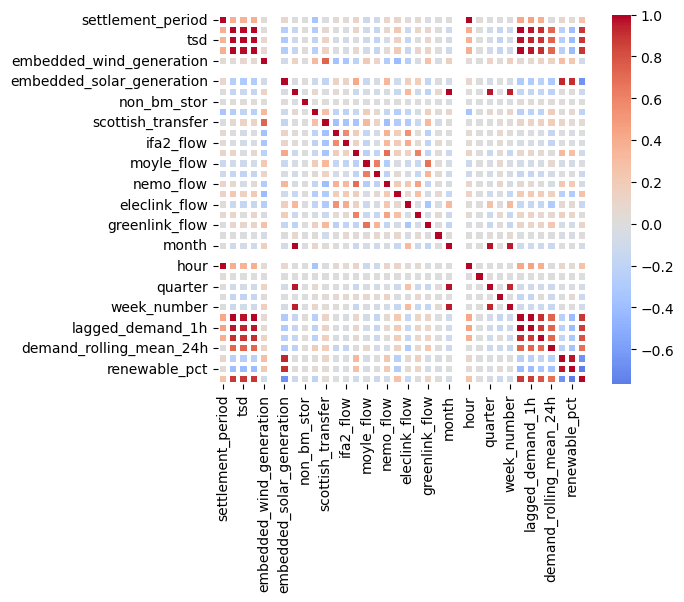

In [9]:
# creating a correlation matrix (numerical columns only)
# correlation of 1 means strong positive correlation and -1 means strong negative correlation

numericdf = df.select_dtypes(include='number')

corr_matrix = numericdf.corr()

sn.heatmap(
    corr_matrix,
    center=0,
    linewidths=1.5,
    square=True,
    cmap='coolwarm'
)

In [11]:
df['embedded_solar_generation'].corr(df['month'])

-0.06775354953453314

In [13]:
df['embedded_solar_generation'].corr(df['greenlink_flow'])

-0.16039139564631058

Text(0.5, 1.0, 'Relationship Between Demand and Wind Generation')

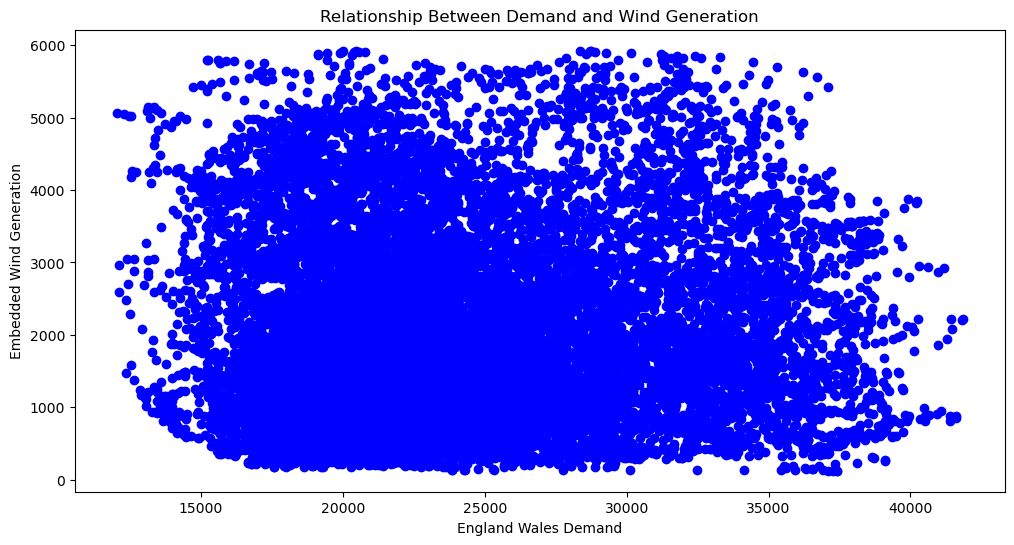

In [17]:
# scatter plot for demand vs wind

df['england_wales_demand'].corr(df['embedded_wind_generation'])

x = df[['england_wales_demand']]
y = df['embedded_wind_generation']

plt.figure(figsize=[12,6])

plt.scatter(x, y, color='blue')

plt.xlabel('England Wales Demand')
plt.ylabel('Embedded Wind Generation')
plt.title('Relationship Between Demand and Wind Generation')

Text(0.5, 1.0, 'Relationship Between Demand and Solar Generation')

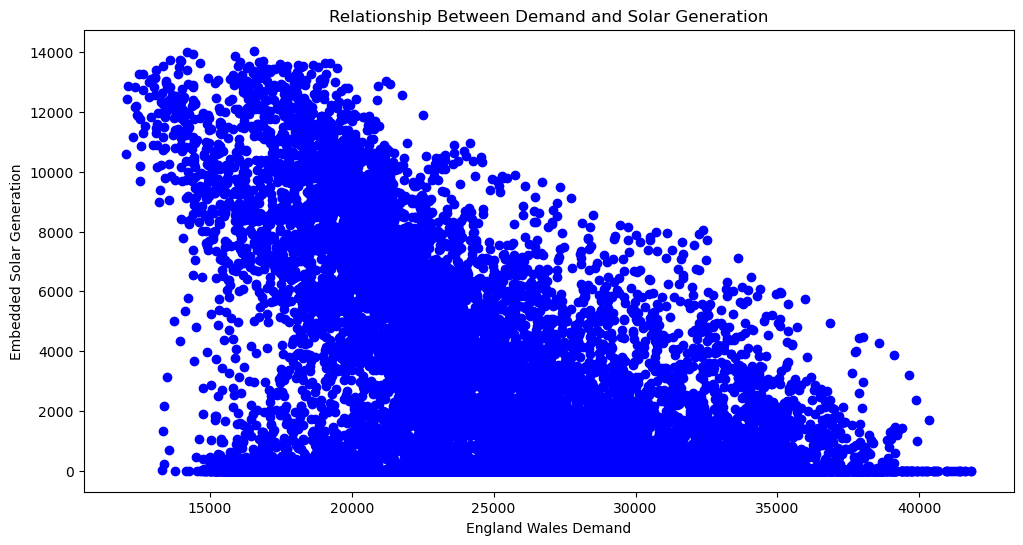

In [19]:
# scatter plot for demand vs solar

df['england_wales_demand'].corr(df['embedded_solar_generation'])

x = df[['england_wales_demand']]
y = df['embedded_solar_generation']

plt.figure(figsize=[12,6])

plt.scatter(x, y, color='blue')

plt.xlabel('England Wales Demand')
plt.ylabel('Embedded Solar Generation')
plt.title('Relationship Between Demand and Solar Generation')

Text(0.5, 1.0, 'Relationship Between Solar Generation and Renewable Pct (%)')

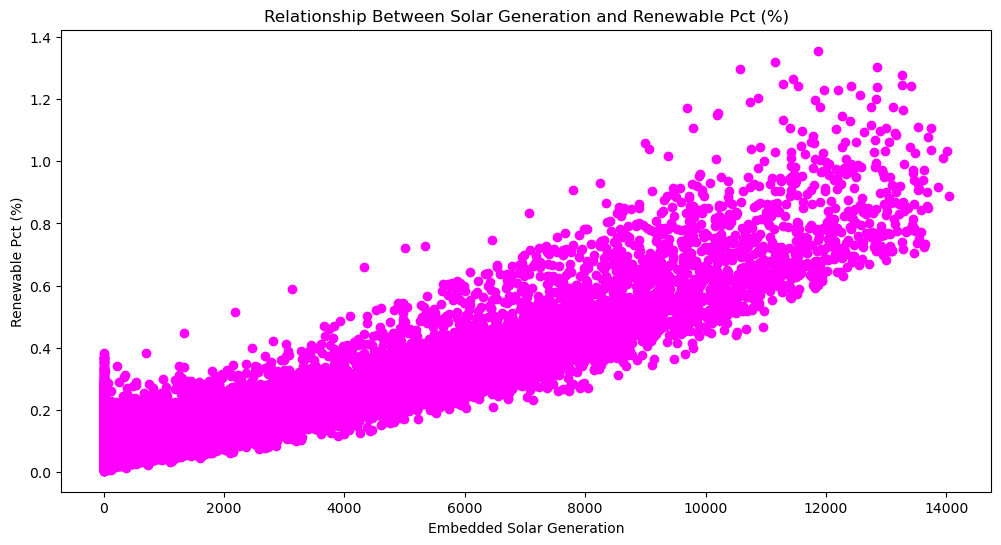

In [25]:
df['embedded_solar_generation'].corr(df['renewable_pct'])

# very strong correlation between embedded solar generation and renewable pct

x = df[['embedded_solar_generation']]
y = df['renewable_pct']

plt.figure(figsize=[12,6])

plt.scatter(x, y, color='magenta')

plt.xlabel('Embedded Solar Generation')
plt.ylabel('Renewable Pct (%)')
plt.title('Relationship Between Solar Generation and Renewable Pct (%)')

In [29]:
# creating a pivot table (hour x month average demand)

pivot = df.pivot_table(
    index='hour',
    columns='month',
    values='england_wales_demand',
    aggfunc='mean'
)

pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
hour,,,,,,,,,,,,
0,24710.661290,24267.571429,22678.596774,19760.466667,18877.096774,19343.733333,19675.096774,19008.338710,19067.700000,20133.609375,22737.500000,23248.790323
1,24441.725806,23928.696429,22367.274194,19536.933333,18382.000000,18733.500000,19035.000000,18343.016129,18578.566667,19845.806452,22296.550000,22960.951613
2,23553.774194,22994.089286,21506.645161,19226.100000,17861.903226,18122.183333,18412.354839,17702.387097,18068.466667,19389.516129,21369.216667,21978.080645
3,22734.516129,22112.017857,20769.532258,18464.600000,17280.241935,17437.383333,17761.741935,17095.709677,17517.700000,18666.145161,20500.716667,21046.354839
4,22181.419355,21481.410714,20450.258065,18091.633333,16937.838710,16926.483333,17363.306452,16787.580645,17245.050000,18266.983871,19970.516667,20410.612903
5,22826.096774,22166.196429,21118.580645,18667.600000,17060.338710,16979.933333,17407.451613,16853.709677,17777.016667,18688.338710,20382.466667,20665.758065
6,26055.500000,25416.053571,23744.903226,20770.116667,18764.935484,18619.566667,19017.661290,18202.935484,20187.266667,21489.032258,23431.933333,23416.919355
7,29971.209677,28981.232143,26418.677419,23095.883333,20467.451613,20435.883333,20915.596774,19890.290323,22671.766667,24592.548387,26933.566667,26767.500000
8,32440.258065,31289.303571,26796.596774,23637.783333,20778.419355,20876.300000,21765.048387,20771.048387,23470.283333,26282.532258,28823.450000,29137.338710


In [31]:
# creating a pivot table (day x month average wind generation)

pivot2 = df.pivot_table(
    index='day',
    columns='month',
    values='embedded_wind_generation',
    aggfunc='mean'
)

pivot2

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,3609.250000,1959.000000,899.041667,2305.937500,970.791667,2833.750000,637.895833,1414.020833,3245.875000,2096.187500,3644.250000,3990.208333
2,1672.979167,2068.937500,1506.208333,2582.104167,1016.708333,2189.291667,1213.979167,803.833333,1334.291667,2944.062500,2602.854167,2283.958333
3,1443.583333,3204.750000,1468.083333,2427.812500,1883.833333,4095.708333,1550.958333,1823.979167,1679.208333,4295.145833,5096.416667,1918.500000
4,1021.166667,4249.687500,2567.208333,2507.854167,1634.500000,2816.562500,3456.625000,4015.708333,1175.208333,5708.958333,3637.208333,2198.312500
5,2457.208333,1615.041667,3523.916667,2681.083333,1322.854167,1553.645833,3395.625000,4032.020833,969.770833,4470.875000,2330.645833,3415.687500
6,3580.208333,1282.937500,2959.229167,1634.354167,551.250000,1340.437500,1122.770833,1551.333333,2394.291667,2564.750000,871.145833,3047.395833
7,2792.291667,3103.625000,1302.812500,618.041667,615.541667,882.562500,2546.666667,2655.333333,3444.583333,2040.500000,1049.125000,2574.604167
8,1286.729167,1048.083333,1554.083333,391.104167,662.333333,1892.895833,1079.562500,2373.770833,1254.270833,1464.875000,949.270833,3159.458333
9,1598.479167,1948.479167,1015.562500,721.291667,776.416667,1448.020833,854.104167,3050.645833,1819.375000,2129.854167,2002.791667,4897.104167


In [33]:
# creating a pivot table (day x month average solar generation)

pivot3 = df.pivot_table(
    index='day',
    columns='month',
    values='embedded_solar_generation',
    aggfunc='mean'
)

pivot3

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,85.625000,487.250000,2578.687500,4108.937500,4039.187500,3566.312500,3090.187500,2432.833333,2776.479167,1367.500000,1409.395833,94.645833
2,1039.750000,1494.958333,2580.000000,4129.479167,3915.604167,4375.500000,3145.062500,3386.458333,2165.166667,1230.479167,1754.229167,1133.041667
3,976.979167,790.208333,2620.729167,3551.562500,3494.479167,2880.604167,4199.770833,2432.145833,1863.583333,318.020833,572.958333,1172.104167
4,237.250000,494.375000,2799.333333,3374.416667,2997.541667,3729.729167,4025.020833,2197.208333,2468.437500,1710.250000,680.583333,261.979167
5,93.187500,1201.104167,2746.208333,4095.208333,3086.750000,2102.687500,2071.250000,3706.291667,3250.416667,2056.583333,497.041667,553.000000
6,380.625000,1820.791667,2552.083333,4281.854167,3593.645833,3661.312500,2365.062500,3889.354167,2917.541667,2620.666667,578.020833,428.020833
7,915.750000,353.375000,1449.541667,4266.729167,3505.312500,2362.083333,3900.770833,2550.229167,1774.708333,1131.625000,499.291667,109.666667
8,260.979167,193.833333,2556.270833,3868.375000,2865.645833,3454.791667,4912.250000,3814.354167,3374.937500,1272.229167,1150.770833,377.479167
9,1161.958333,397.354167,2609.187500,3514.958333,4640.270833,2785.395833,3979.916667,3870.937500,2892.937500,1378.125000,699.916667,146.458333


In [37]:
# now saving the csv file

df.to_csv('correlation_demand_data_2025.csv')
print('CSV saved successfully.')

CSV saved successfully.
